# A_3a — Delay statistics and delay magnitude regression

**Input:** `Results/07.xlsx`
**Output:** delay statistics by phase, OLS results (SI Table 9)

Separates schedule overruns from early-stage anticipations, and computes
marginal deviations between consecutive reports to locate variance by phase.
Confidence intervals use the t-distribution.

The OLS on log-transformed standardised delay tests whether physical scale and
technical characteristics explain the magnitude of overruns. Capacity and line
length enter as categories with an explicit missing level, which avoids both
listwise deletion and the imputation of zero length to nodal infrastructure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import scipy.stats as st
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_excel("Results/07.xlsx", header=[0,1], index_col=0)

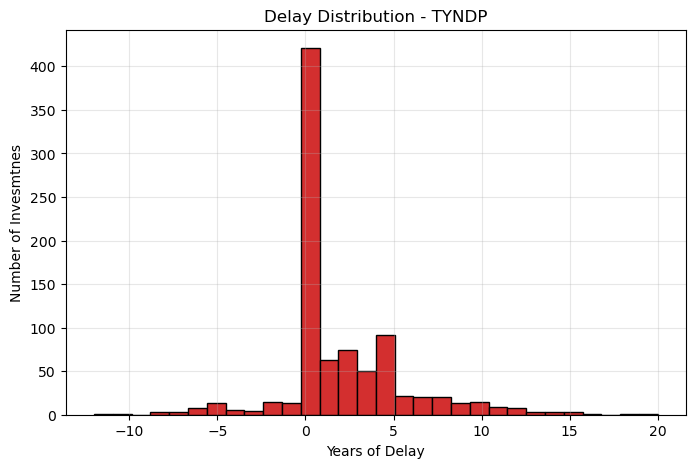

In [3]:
delay = df[('meta', 'delay')]

plt.figure(figsize=(8,5))
plt.hist(delay, bins=30, color='#D32F2F', edgecolor='black')
plt.xlabel('Years of Delay')
plt.ylabel('Number of Invesmtnes')
plt.title('Delay Distribution - TYNDP')
plt.grid(True, alpha=0.3)

plt.savefig('Images/delay_histogram_tyndp.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
avg_delay = delay.mean()
median_delay = delay.median()

print(f"Average deviation from the commissioning date declared at the beginning:    {avg_delay:.2f} years")
print(f"Median deviation from the commissioning date declared at the beginning:     {median_delay:.2f} years")
print("-" * 50)

pos_delays = delay[delay > 0]
neg_delays = delay[delay < 0]

avg_pos_delay = pos_delays.mean()
median_pos_delay = pos_delays.median()
std_pos_delay = pos_delays.std()

n_pos = len(pos_delays)
standard_error = std_pos_delay / np.sqrt(n_pos)

margin_of_error = st.t.ppf(0.975, n_pos - 1) * standard_error

ci_lower = avg_pos_delay - margin_of_error
ci_upper = avg_pos_delay + margin_of_error

avg_neg_delay = neg_delays.mean()
min_del = delay.min()
max_del = delay.max()

print(f"Average Delay:                {avg_pos_delay:.2f} ± {margin_of_error:.2f}")
print(f"95% CI of Delay:              [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Median of Delay (>0):         {median_pos_delay:.2f}")
print(f"Average investments jumps ahead of schedule (<0): {avg_neg_delay:.2f}")
print("-" * 50)
print(f"Max jumps ahead of schedule:      {min_del:.2f}")
print(f"Max delay:                        {max_del:.2f}")

Average deviation from the commissioning date declared at the beginning:    1.80 years
Median deviation from the commissioning date declared at the beginning:     0.00 years
--------------------------------------------------
Average Delay:                4.66 ± 0.34
95% CI of Delay:              [4.32, 5.00]
Median of Delay (>0):         4.00
Average investments jumps ahead of schedule (<0): -3.88
--------------------------------------------------
Max jumps ahead of schedule:      -12.00
Max delay:                        20.00


### Number of invetment delayed


In [5]:
count_delay = (df[('meta', 'delay')] > 0).sum()
print(f"Number of rows with a delay > 0: {count_delay}")


Number of rows with a delay > 0: 398


In [6]:
count_delay_6 = (df[('meta', 'delay')] > 6).sum()
print(f"Number of rows with a delay longer than 6 years: {count_delay_6}")

Number of rows with a delay longer than 6 years: 98


### Number of investment delayed out ot the investment present for more than one report

In [7]:
df[('meta', 'N_report_year')] = df[('meta', 'Inv_Last_year_present')] - df[('meta', 'Inv_First_year_present')]

more_than_one_year = (df[('meta', 'N_report_year')] > 0).sum()
print(f"Number of investments reported for more than one report: {more_than_one_year}")

Number of investments reported for more than one report: 725


In [8]:
Percentage_inv_delayed = count_delay/more_than_one_year
print(f"Percentage of invesmtnets delayed: {Percentage_inv_delayed}")

Percentage of invesmtnets delayed: 0.5489655172413793


In [9]:
Percentage_inv_delayed_6 = count_delay_6/more_than_one_year
print(f"Percentage of invesmtnets delayed more than 6 years: {Percentage_inv_delayed_6}")

Percentage of invesmtnets delayed more than 6 years: 0.13517241379310344


### Delay per status

In [10]:
years = ['2010', '2012', '2013', '2014', '2015', '2016', '2018', '2020', '2022', '2024', '2026']

for i in range(1, len(years)):
    curr_year = years[i]
    prev_year = years[i-1]
    
    delay_val = (df[(curr_year, 'Inv_Commissioning_Year_Standardized')] - 
                 df[(prev_year, 'Inv_Commissioning_Year_Standardized')])

    is_present_both = (df[(prev_year, 'Inv_Is_Present')] == 1) & (df[(curr_year, 'Inv_Is_Present')] == 1)
    
    df[(curr_year, 'delay')] = delay_val.where(is_present_both)

delay_columns = [(y, 'delay') for y in years[1:]]


In [11]:
status_delay_cols = []
for yr in years:
    if (yr, 'Inv_Status') in df.columns and (yr, 'delay') in df.columns:
        status_delay_cols.append((yr, 'Inv_Status'))
        status_delay_cols.append((yr, 'delay'))

long_df = df[status_delay_cols].stack(0)

long_list = long_df[['Inv_Status', 'delay']].dropna(subset=['delay'])

long_list_final = long_list.reset_index(drop=True)


C:\Users\damia\AppData\Local\Temp\ipykernel_9488\2782449160.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df[status_delay_cols].stack(0)


In [12]:
conditions = [
    long_list_final['delay'] > 0,
    long_list_final['delay'] < 0,
    long_list_final['delay'] == 0
]
choices = ['Delay (>0)', 'Anticipation (<0)', 'On Time (=0)']

long_list_final['Category'] = np.select(conditions, choices, default='Unknown')

analysis = long_list_final.groupby(['Inv_Status', 'Category']).size().unstack(fill_value=0)

analysis_pct = analysis.div(analysis.sum(axis=1), axis=0) * 100

summary = analysis.copy()
for col in analysis.columns:
    summary[f'{col} %'] = analysis_pct[col].round(2)

ordered_cols = [
    'Delay (>0)', 'Delay (>0) %',
    'Anticipation (<0)', 'Anticipation (<0) %',
    'On Time (=0)', 'On Time (=0) %'
]
summary = summary[ordered_cols]


In [13]:
pos_stats = long_list_final[long_list_final['delay'] > 0].groupby('Inv_Status')['delay'].agg(['count', 'mean', 'std'])
neg_stats = long_list_final[long_list_final['delay'] < 0].groupby('Inv_Status')['delay'].agg(['count', 'mean', 'std'])

# Calculate the 95% CI Margin of Error (moe) using t-distribution
# Formula: t_critical * (standard_deviation / sqrt(sample_size))
pos_stats['moe'] = st.t.ppf(0.975, pos_stats['count'] - 1) * (pos_stats['std'] / np.sqrt(pos_stats['count']))
neg_stats['moe'] = st.t.ppf(0.975, neg_stats['count'] - 1) * (neg_stats['std'] / np.sqrt(neg_stats['count']))

# Add numerical values to summary (Rounded to 1 decimal place for publication consistency)
summary['Avg Delay Magnitude'] = pos_stats['mean'].round(1)
summary['Delay CI Lower'] = (pos_stats['mean'] - pos_stats['moe']).round(1)
summary['Delay CI Upper'] = (pos_stats['mean'] + pos_stats['moe']).round(1)

summary['Avg Anticipation Magnitude'] = neg_stats['mean'].round(1)
summary['Anticipation CI Lower'] = (neg_stats['mean'] - neg_stats['moe']).round(1)
summary['Anticipation CI Upper'] = (neg_stats['mean'] + neg_stats['moe']).round(1)

cols_to_fill = [
    'Avg Delay Magnitude', 'Delay CI Lower', 'Delay CI Upper',
    'Avg Anticipation Magnitude', 'Anticipation CI Lower', 'Anticipation CI Upper'
]
summary[cols_to_fill] = summary[cols_to_fill].fillna(0)

def format_ci_string(row, mean_col, low_col, up_col):
    if row[mean_col] == 0:
        return "0" 
    if row[low_col] == 0 and row[up_col] == 0:
        return f"{row[mean_col]:.1f} (N/A)"
        
    return f"{row[mean_col]:.1f} (95% CI, {row[low_col]:.1f}–{row[up_col]:.1f})"

summary['Formatted Delay'] = summary.apply(
    lambda row: format_ci_string(row, 'Avg Delay Magnitude', 'Delay CI Lower', 'Delay CI Upper'), axis=1
)
summary['Formatted Anticipation'] = summary.apply(
    lambda row: format_ci_string(row, 'Avg Anticipation Magnitude', 'Anticipation CI Lower', 'Anticipation CI Upper'), axis=1
)

final_cols = [
    'Delay (>0)', 'Delay (>0) %', 'Formatted Delay',
    'Anticipation (<0)', 'Anticipation (<0) %', 'Formatted Anticipation',
    'On Time (=0)', 'On Time (=0) %'
]

summary_final = summary[[col for col in final_cols if col in summary.columns]]

print(summary_final)

Category    Delay (>0)  Delay (>0) %        Formatted Delay  \
Inv_Status                                                    
1.0                161         35.23  3.9 (95% CI, 3.4–4.3)   
2.0                215         40.41  2.5 (95% CI, 2.3–2.8)   
3.0                319         47.19  2.3 (95% CI, 2.1–2.4)   
4.0                124         35.13  1.8 (95% CI, 1.6–2.0)   
5.0                  8         11.59  1.1 (95% CI, 0.8–1.4)   
6.0                  0          0.00                      0   

Category    Anticipation (<0)  Anticipation (<0) %    Formatted Anticipation  \
Inv_Status                                                                     
1.0                        38                 8.32  -3.6 (95% CI, -4.2–-2.9)   
2.0                        51                 9.59  -3.6 (95% CI, -4.3–-2.8)   
3.0                        31                 4.59  -1.9 (95% CI, -2.3–-1.6)   
4.0                        11                 3.12   -2.3 (95% CI, -4.7–0.2)   
5.0            

### Linear Regression

In [14]:
df_meta = df['meta'].copy()

nan_counts = df_meta.isna().sum()
nan_percentages = (df_meta.isna().mean() * 100).round(2)

meta_variables_report = pd.DataFrame({
    'Missing Values (Count)': nan_counts,
    'Missing Values (%)': nan_percentages
})

print("==================================================")
print(meta_variables_report.sort_values(by='Missing Values (Count)'))
print("--------------------------------------------------")
print(f"Total investments in the dataset: {len(df_meta)}")
print("==================================================")

                                       Missing Values (Count)  \
Column                                                          
Inv_index                                                   0   
Project_Region                                              0   
Project_Jurisdiction                                        0   
Inv_Years_present                                           0   
N_report_year                                               0   
Inv_Last_year_present                                       0   
Inv_First_year_present                                      0   
Project_Name                                                8   
Project_Country_ISO3                                       22   
Project_N_Countries                                        22   
Inv_last_reported_commissioning_year                       24   
duration                                                   24   
Inv_Description                                            36   
Project_ID               

In [15]:
df[('meta', 'delay_st')] = df[('meta', 'delay')] / df[('meta', 'N_report_year')]
df[('meta', 'delay_st')] = df[('meta', 'delay_st')].replace([np.inf, -np.inf], np.nan)

cols = [
    'delay_st', 'Project_Jurisdiction', 'Project_Region', 'Infr_Type', 
    'Inv_Element_Category', 'Inv_Environment', 'Inv_Technology[AC/DC]', 
    'Inv_Capacity [MW]', 'Inv_Line length [km]'
]

existing_cols = [('meta', c) for c in cols if ('meta', c) in df.columns]
df_reg = df[existing_cols].copy()
df_reg.columns = [c[1] for c in df_reg.columns] 

if 'Inv_Technology[AC/DC]' in df_reg.columns:
    df_reg = df_reg.rename(columns={'Inv_Technology[AC/DC]': 'Inv_Technology'})

def discretize_length(val):
    if pd.isna(val): return 'Missing'
    if val == 0: return '0km/Nodal'
    if val <= 50: return 'Short (<50km)'
    if val <= 150: return 'Medium (50-150km)'
    return 'Long (>150km)'

def discretize_capacity(val):
    if pd.isna(val): return 'Missing'
    if val <= 500: return 'Low (<=500MW)'
    if val <= 1500: return 'Medium (500-1500MW)'
    return 'High (>1500MW)'

df_reg['Length_Class'] = df_reg['Inv_Line length [km]'].apply(discretize_length)
df_reg['Capacity_Class'] = df_reg['Inv_Capacity [MW]'].apply(discretize_capacity)

df_reg['Is_New_Infr'] = (df_reg['Infr_Type'].str.strip().str.lower() == 'new').astype(int)

cat_cols = [
    'Project_Jurisdiction', 'Project_Region', 
    'Inv_Element_Category', 'Inv_Technology',
    'Length_Class', 'Capacity_Class'
]

for c in cat_cols:
    if c in df_reg.columns:
        df_reg[c] = df_reg[c].fillna('Unknown').astype(str).str.strip()

df_reg = df_reg.dropna(subset=['delay_st'])
df_reg = df_reg[df_reg['delay_st'] > 0].copy()

print(f"🚀 Righe valide per il modello: {len(df_reg)}")

if len(df_reg) > 0:
    y = np.log(df_reg['delay_st'])
    
    X_raw = df_reg[cat_cols]
    X_encoded = pd.get_dummies(X_raw, drop_first=True).astype(float)
    
    X_encoded['Is_New_Infr'] = df_reg['Is_New_Infr']
    
    if 'Inv_Element_Category_Unknown' in X_encoded.columns:
        X_encoded = X_encoded.drop(columns=['Inv_Element_Category_Unknown'])

    X_encoded = sm.add_constant(X_encoded)
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_encoded.columns
    vif_data["VIF"] = [variance_inflation_factor(X_encoded.values, i) for i in range(X_encoded.shape[1])]
    print(vif_data[vif_data["Feature"] != "const"].round(2).sort_values('VIF', ascending=False))
    
    model = sm.OLS(y, X_encoded)
    results = model.fit()
    print(results.summary())

🚀 Righe valide per il modello: 398
                                      Feature   VIF
8              Length_Class_Medium (50-150km)  6.33
7                  Length_Class_Long (>150km)  5.85
10                 Length_Class_Short (<50km)  4.19
11               Capacity_Class_Low (<=500MW)  3.64
9                        Length_Class_Missing  3.06
4   Inv_Element_Category_Nodal Infrastructure  2.87
12         Capacity_Class_Medium (500-1500MW)  2.58
13                     Capacity_Class_Missing  2.43
5                           Inv_Technology_DC  2.03
6                      Inv_Technology_Unknown  1.91
1               Project_Jurisdiction_Internal  1.25
14                                Is_New_Infr  1.25
2                     Project_Region_Extra-EU  1.16
3                      Project_Region_Unknown  1.12
                            OLS Regression Results                            
Dep. Variable:               delay_st   R-squared:                       0.117
Model:                     